In [15]:
#!pip install tqdm

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
import lightgbm as lgbm
import catboost

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from importlib import reload

import pipeline
reload(pipeline)
print(dir(pipeline))

import feature_eng
reload(feature_eng)
print(dir(feature_eng))

['KFold', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy_score', 'catboost', 'catboost_cv', 'catboost_cv_temporal', 'feature_eng', 'find_hyperparameters_catboost', 'find_hyperparameters_lgbm', 'lgbm', 'lgbm_cv', 'lgbm_cv_temporal', 'linear_model', 'np', 'pd', 'plt', 'sns', 'train_catboost', 'train_lgbm', 'train_test_split']
['FE_benchmark', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__warningregistry__', 'add_cross_sectional_context_features', 'add_rowwise_features', 'add_temporal_FE']


In [17]:
# Load data
X_train = pd.read_csv("data/X_train.csv", index_col="ROW_ID")
X_test = pd.read_csv("data/X_test.csv", index_col="ROW_ID")
y_train = pd.read_csv("data/y_train.csv", index_col="ROW_ID")


### Fitting a lightgbm using cross validation

In [18]:
def plot_feature_importances(lgbm_models, features):
    feature_importances = pd.DataFrame(
        [
            model_lgbm.feature_importance(importance_type="gain")
            for model_lgbm in lgbm_models
        ],
        columns=features,
    )

    feature_importances = feature_importances.loc[
        :, feature_importances.mean(0).sort_values(ascending=False).index[:20]
    ]

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=feature_importances,
        orient="h",
        order=feature_importances.mean().sort_values(ascending=False).index,
    )

In [19]:
lgbm_performance = {}

we have 53 features after adding benchmark features

LightGBM on benchmark and normal cv
Fold 1 - Accuracy: 51.77%
Fold 2 - Accuracy: 52.43%
Fold 3 - Accuracy: 52.09%
Fold 4 - Accuracy: 52.11%
Fold 5 - Accuracy: 51.90%
Fold 6 - Accuracy: 52.24%
Fold 7 - Accuracy: 52.16%
Fold 8 - Accuracy: 51.69%
Accuracy: 52.05% [51.82 ; 52.28] (+- 0.23)


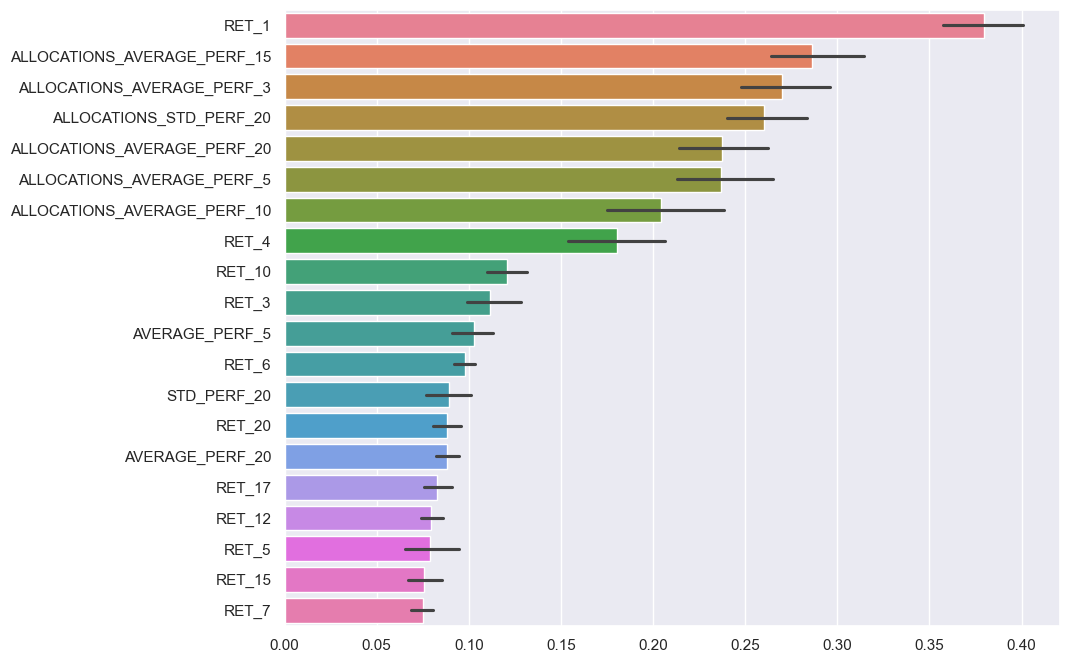

In [ ]:
# Add benchmark features
X_train, X_test, features = feature_eng.FE_benchmark(X_train, X_test)

print(f"we have {len(features)} features after adding benchmark features")

print("\nLightGBM on benchmark features")
lgbm_models, lgbm_scores = pipeline.lgbm_cv(
    X_train,
    y_train,
    X_test,
    features,
    num_boost_round=300,
    learning_rate=0.053,
    max_depth=4,
    see_folds=True,
)
lgbm_performance["benchmark"] = lgbm_scores
plot_feature_importances(lgbm_models, features)

we have 77 features after adding benchmark features

LightGBM on benchmark + rowwise features and normal cv
Fold 1 - Accuracy: 51.83%
Fold 2 - Accuracy: 52.35%
Fold 3 - Accuracy: 52.07%
Fold 4 - Accuracy: 52.42%
Fold 5 - Accuracy: 51.87%
Fold 6 - Accuracy: 52.39%
Fold 7 - Accuracy: 52.01%
Fold 8 - Accuracy: 51.60%
Accuracy: 52.07% [51.79 ; 52.34] (+- 0.28)


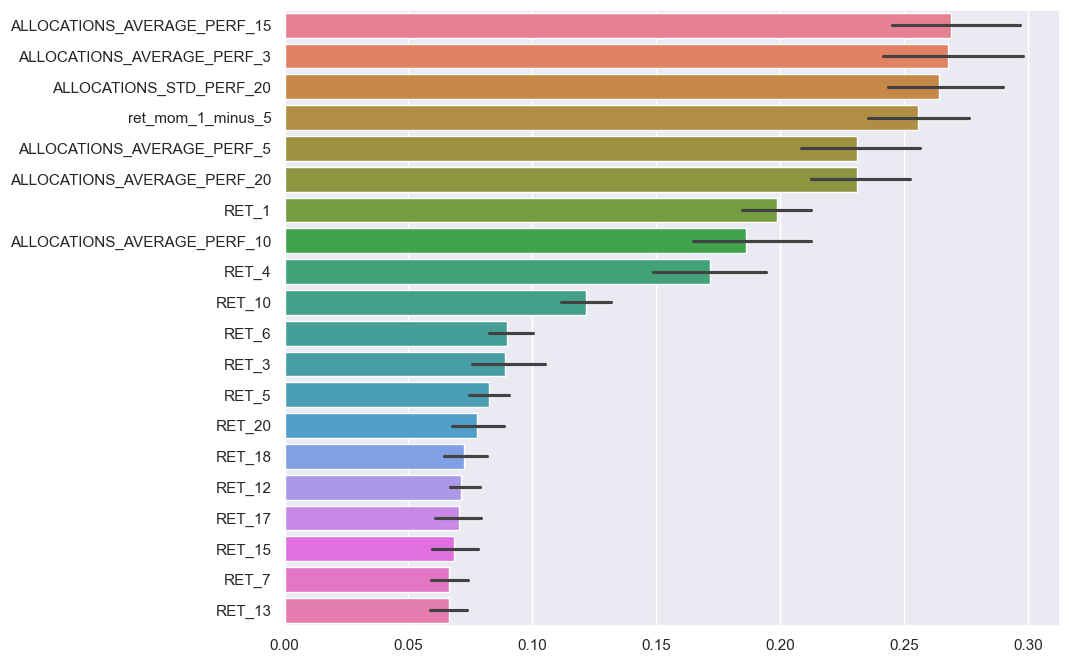

In [ ]:
# Add rowwise features
X_train, X_test, features = feature_eng.add_rowwise_features(X_train, X_test, features)

print(f"we have {len(features)} features after adding rowwise features")

print("\nLightGBM on benchmark + rowwise features")
lgbm_models, lgbm_scores = pipeline.lgbm_cv(
    X_train,
    y_train,
    X_test,
    features,
    num_boost_round=300,
    learning_rate=0.053,
    max_depth=4,
    see_folds=True,
)
lgbm_performance["benchmark + rowwise"] = lgbm_scores
plot_feature_importances(lgbm_models, features)

/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:402: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[disp_name] = ts_std.astype(float)
/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:417: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[group_diff_name] = df[col] - tsg_mean
/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:421: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

we have 210 features after adding benchmark features

LightGBM on benchmark + rowwise + cross-sectional features and normal cv
Fold 1 - Accuracy: 52.13%
Fold 2 - Accuracy: 52.22%
Fold 3 - Accuracy: 52.21%
Fold 4 - Accuracy: 52.17%
Fold 5 - Accuracy: 51.54%
Fold 6 - Accuracy: 51.97%
Fold 7 - Accuracy: 52.29%
Fold 8 - Accuracy: 52.24%
Accuracy: 52.10% [51.87 ; 52.33] (+- 0.23)


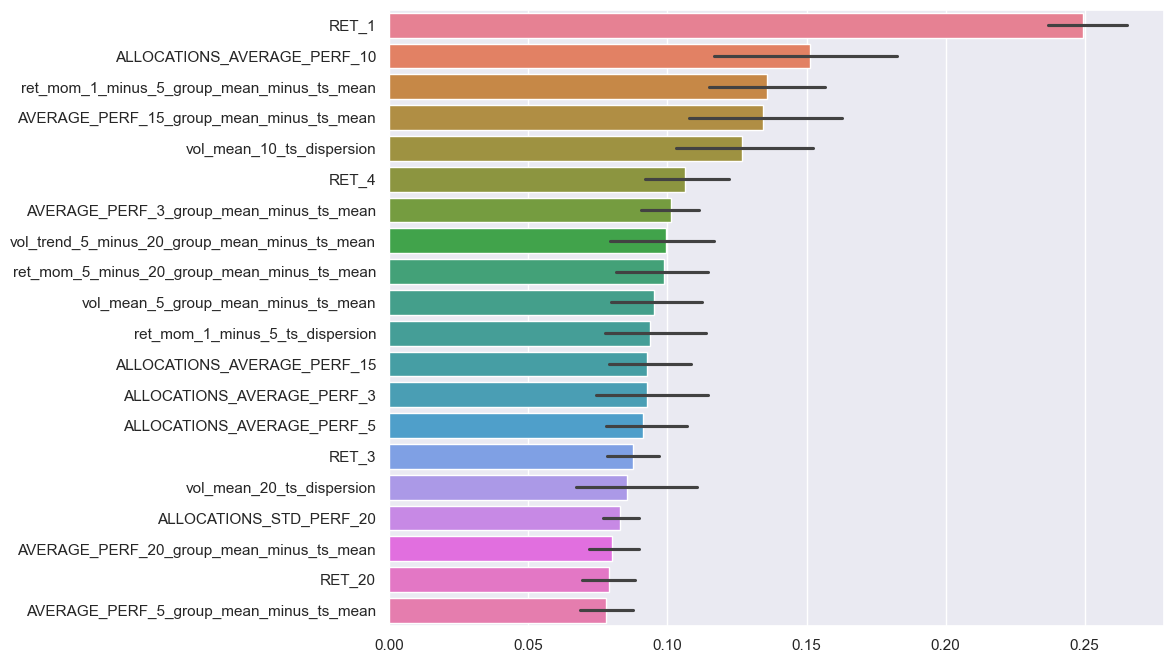

In [ ]:
# Add cross-sectional context features
X_train, X_test, features = feature_eng.add_cross_sectional_context_features(
    X_train, X_test, features
)
print(f"we have {len(features)} features after adding cross-sectional context features")

print("\nLightGBM on benchmark + rowwise + cross-sectional features")
lgbm_models, lgbm_scores = pipeline.lgbm_cv(
    X_train,
    y_train,
    X_test,
    features,
    num_boost_round=300,
    learning_rate=0.053,
    max_depth=4,
    see_folds=True,
)
lgbm_performance["benchmark + rowwise + cross-sectional"] = lgbm_scores
plot_feature_importances(lgbm_models, features)

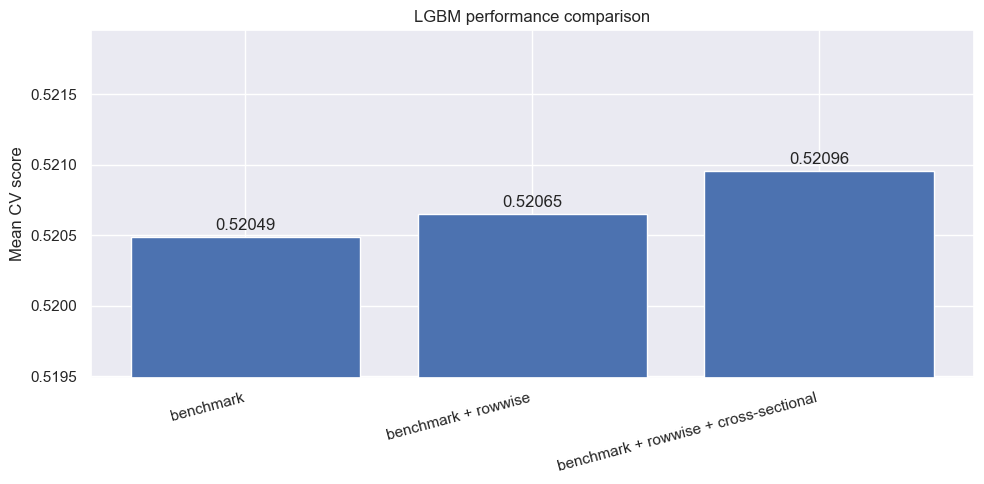

In [61]:
def plot_performance(dict_performance, title="LGBM performance comparison"):
    # compute means
    model_names = list(dict_performance.keys())
    mean_scores = [np.mean(scores) for scores in dict_performance.values()]

    # plot
    plt.figure(figsize=(10, 5))
    plt.bar(model_names, mean_scores)
    plt.ylabel("Mean CV score")
    plt.title(title)
    plt.xticks(rotation=15, ha="right")
    plt.ylim(min(mean_scores) - 0.001, max(mean_scores) + 0.001)

    # optional: print values above bars
    for i, v in enumerate(mean_scores):
        plt.text(i, v + 0.00005, f"{v:.5f}", ha="center")

    plt.tight_layout()
    plt.show()

plot_performance(lgbm_performance)

# fitting Catboost with CV

In [63]:
# Reset variable to avoid confusion
X_train, X_test, features = None, None, None

# Load data
X_train = pd.read_csv("data/X_train.csv", index_col="ROW_ID")
X_test = pd.read_csv("data/X_test.csv", index_col="ROW_ID")
y_train = pd.read_csv("data/y_train.csv", index_col="ROW_ID")

catboost_performance = {}

In [64]:
# Add benchmark features
X_train, X_test, features = feature_eng.FE_benchmark(X_train, X_test)

print(f"we have {len(features)} features after adding benchmark features")

print("\nCatBoost on benchmark features")
catboost_models, catboost_scores = pipeline.catboost_cv(
    X_train,
    y_train,
    X_test,
    features,
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    see_folds=True,
)
catboost_performance["benchmark"] = catboost_scores


we have 53 features after adding benchmark features

CatBoost on benchmark features
Fold 1 - Accuracy: 51.44%
Fold 2 - Accuracy: 52.03%
Fold 3 - Accuracy: 52.26%
Fold 4 - Accuracy: 51.72%
Fold 5 - Accuracy: 51.80%
Fold 6 - Accuracy: 52.32%
Fold 7 - Accuracy: 51.77%
Fold 8 - Accuracy: 51.48%
Accuracy: 51.85% [51.54 ; 52.16] (+- 0.31)


In [65]:
# Add rowwise features
X_train, X_test, features = feature_eng.add_rowwise_features(X_train, X_test, features)

print(f"we have {len(features)} features after adding rowwise features")

print("\nCatBoost on benchmark + rowwise features and normal cv")
catboost_models, catboost_scores = pipeline.catboost_cv(
    X_train,
    y_train,
    X_test,
    features,
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    see_folds=True,
)
catboost_performance["benchmark + rowwise"] = catboost_scores

we have 77 features after adding rowwise features

CatBoost on benchmark + rowwise features and normal cv
Fold 1 - Accuracy: 51.35%
Fold 2 - Accuracy: 52.21%
Fold 3 - Accuracy: 52.27%
Fold 4 - Accuracy: 52.10%
Fold 5 - Accuracy: 52.03%
Fold 6 - Accuracy: 52.11%
Fold 7 - Accuracy: 51.83%
Fold 8 - Accuracy: 51.76%
Accuracy: 51.96% [51.68 ; 52.24] (+- 0.28)


In [66]:
# Add cross-sectional context features
X_train, X_test, features = feature_eng.add_cross_sectional_context_features(
    X_train, X_test, features
)
print(f"we have {len(features)} features after adding cross-sectional context features")

print("\nCatBoost on benchmark + rowwise + cross-sectional features")
catboost_models, catboost_scores = pipeline.catboost_cv(
    X_train,
    y_train,
    X_test,
    features,
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    see_folds=True,
)
catboost_performance["benchmark + rowwise + cross-sectional"] = catboost_scores


/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:402: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[disp_name] = ts_std.astype(float)
/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:417: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[group_diff_name] = df[col] - tsg_mean
/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:421: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

we have 234 features after adding cross-sectional context features

CatBoost on benchmark + rowwise + cross-sectional features
Fold 1 - Accuracy: 51.91%
Fold 2 - Accuracy: 52.09%
Fold 3 - Accuracy: 52.60%
Fold 4 - Accuracy: 52.55%
Fold 5 - Accuracy: 51.80%
Fold 6 - Accuracy: 51.79%
Fold 7 - Accuracy: 51.80%
Fold 8 - Accuracy: 52.02%
Accuracy: 52.07% [51.76 ; 52.38] (+- 0.31)


In [73]:
from pipeline import train_catboost

train_catboost(
    X_train,
    y_train,
    X_test,
    features,
    iterations=600,
    learning_rate=0.02,
    depth=8,
    saving_csv=True,
)

Predictions saved to submissions/catboost_FE3.csv


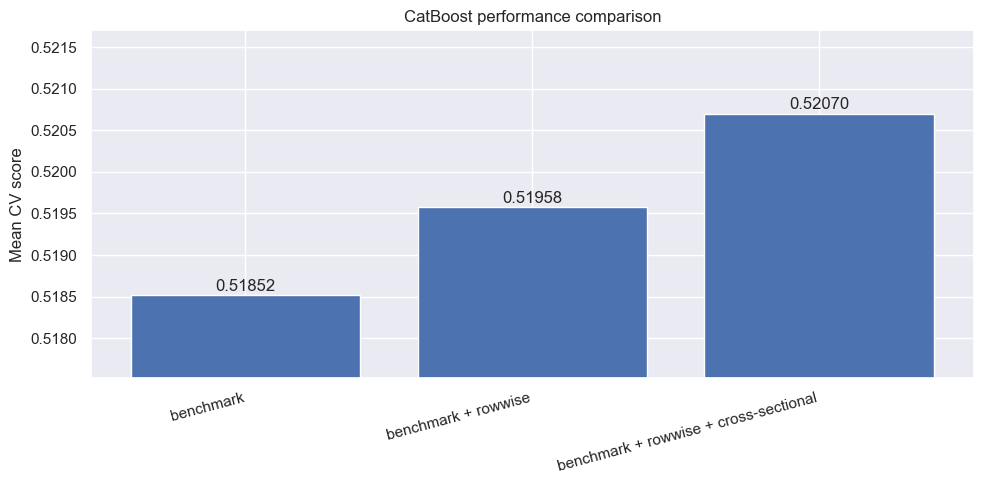

In [62]:
plot_performance(catboost_performance,title="CatBoost performance comparison")

# Try to use the reconctructed 


In [56]:
#reset variable to avoid confusion
X_train, X_test, features = None, None, None

#load data
X_train = pd.read_csv("data/X_train_reconstructed.csv", index_col="ROW_ID")
X_test = pd.read_csv("data/X_test.csv", index_col="ROW_ID")
y_train = pd.read_csv("data/y_train.csv", index_col="ROW_ID")


X_train, X_test, features = feature_eng.FE_benchmark(X_train, X_test)
X_train, X_test, features = feature_eng.add_rowwise_features(X_train, X_test, features)
X_train, X_test, features = feature_eng.add_temporal_FE(X_train, X_test, features)
X_train, X_test, features = feature_eng.add_cross_sectional_context_features(
    X_train, X_test, features
)

print (f"we have {len(features)} features after adding all features")

/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:402: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[disp_name] = ts_std.astype(float)
/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:417: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[group_diff_name] = df[col] - tsg_mean
/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:421: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

we have 241 features after adding all features


/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:402: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[disp_name] = ts_std.astype(float)
/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:417: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[group_diff_name] = df[col] - tsg_mean
/Users/martino.orioligmail.com/QRT-ENS Data Challenge/QRT-ENS-Data-Challenge/feature_eng.py:421: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

### lgbm temporal

In [57]:
lgbm_models_temporal, lgbm_scores_temporal = pipeline.lgbm_cv_temporal(
    X_train,
    y_train,
    features,
    num_boost_round=500,
    learning_rate=0.05,
    max_depth=6,
    see_folds=True,
)

Fold 1 | train: [DATE_0001 -> DATE_0280] | test: [DATE_0281 -> DATE_0560] | Accuracy: 49.66%
Fold 2 | train: [DATE_0001 -> DATE_0560] | test: [DATE_0561 -> DATE_0840] | Accuracy: 49.88%
Fold 3 | train: [DATE_0001 -> DATE_0840] | test: [DATE_0841 -> DATE_1120] | Accuracy: 49.88%
Fold 4 | train: [DATE_0001 -> DATE_1120] | test: [DATE_1121 -> DATE_1400] | Accuracy: 50.05%
Fold 5 | train: [DATE_0001 -> DATE_1400] | test: [DATE_1401 -> DATE_1680] | Accuracy: 50.22%
Fold 6 | train: [DATE_0001 -> DATE_1680] | test: [DATE_1681 -> DATE_1960] | Accuracy: 50.06%
Fold 7 | train: [DATE_0001 -> DATE_1960] | test: [DATE_1961 -> DATE_2240] | Accuracy: 49.94%
Fold 8 | train: [DATE_0001 -> DATE_2240] | test: [DATE_2241 -> DATE_2522] | Accuracy: 50.76%
Accuracy: 50.06% [49.75 ; 50.36] (+- 0.31)


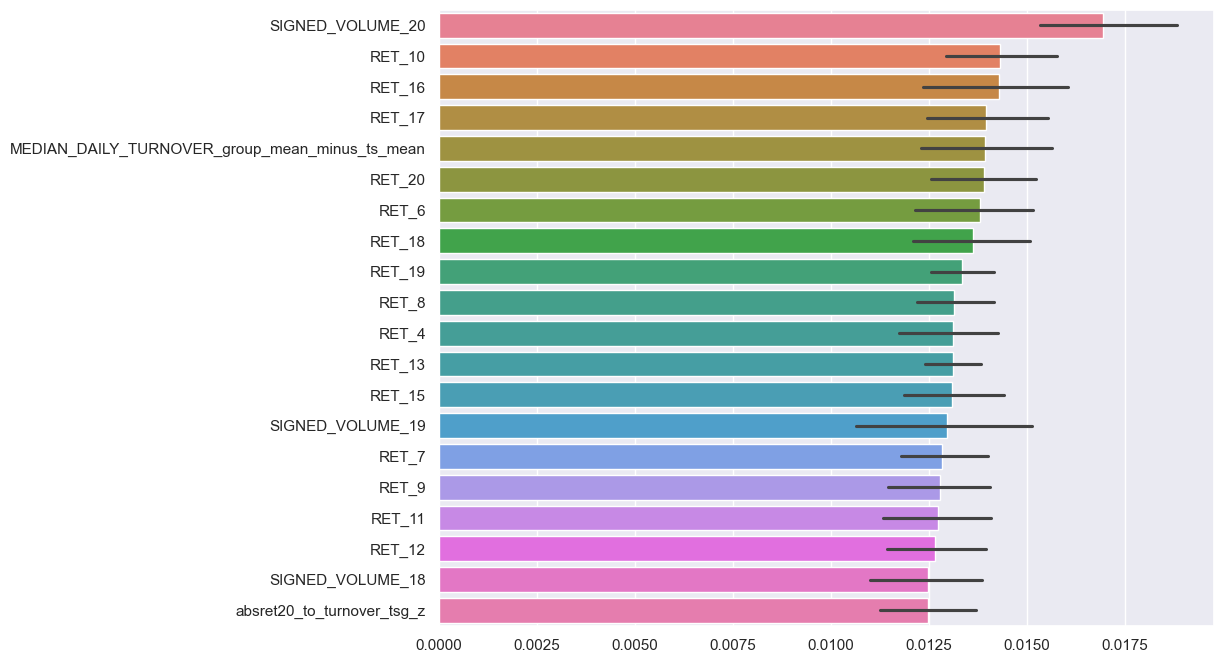

In [58]:
plot_feature_importances(lgbm_models_temporal, features)

In [ ]:
#pipeline.train_lgbm_temporal(X_train, y_train, features, saving_csv=False)

## Catboost temporal

In [ ]:
catboost_models_temporal, catboost_scores_temporal = pipeline.catboost_cv_temporal(
    X_train,
    y_train,
    features,
)

In [ ]:
#pipeline.train_catboost_temporal(X_train, y_train, features, saving_csv=False)